In [1]:
import torch
import torch.nn as nn
import torch.utils.data as Data
import matplotlib.pyplot as plt
import numpy as np
import PIL.Image
import os

In [2]:
device = torch.device("cuda:0"if torch.cuda.is_available()else "cpu")

In [3]:
def loadData():#加载数据的方法
    xData = list()#存图片数据
    yData = list()#存标签，12类，所以是0-11
    labelNameDict = dict()
    dataPath = "./GarbageClassification/"#数据路径
    listdir  = os.listdir(dataPath)#遍历文件夹下所有子文件夹
    for label,labelName in enumerate(listdir):
        labelNameDict[label] = labelName
        for filename in os.listdir(dataPath + labelName):#索引和名称进行对应
           if not filename.endswith('.jpg'):#判断图片格式
               continue
           imageSize = (32,32)#尺寸的缩放
           x = PIL.Image.open(dataPath + labelName + '/' +filename).resize(imageSize)
           x = torch.FloatTensor(np.array(x))/255#归一化
           #[32,32,3]->[3,32,32]#32是像素比，3是通道数，需要转化为通道在前面
           x = x.permute(2,0,1)#这相当于就是索引
           xData.append(x)
           yData.append(label)#类别对应的序号0到11
    return xData, yData, labelNameDict

In [4]:
xData, yData, labelNameDict = loadData()

In [5]:
len(xData),len(yData),xData[0].shape,yData[0]

(15515, 15515, torch.Size([3, 32, 32]), 0)

In [6]:
class Dataset(Data.Dataset):
    def __init__(self):
        pass
    def __len__(self):
        return len(xData)
    def __getitem__(self, i):
        return xData[i], yData[i]

In [7]:
dataset = Dataset()

In [8]:
loader = Data.DataLoader(dataset=dataset,
                         batch_size=8,
                         shuffle=True,
                         drop_last=True)

In [9]:
x, y = next(iter(loader))

In [10]:
len(loader), x.shape, y

(1939, torch.Size([8, 3, 32, 32]), tensor([4, 4, 9, 4, 4, 4, 6, 7]))

In [11]:
class Model(nn.Module):#下面是做卷积
    def __init__(self):
        super().__init__()
        self.cnn1 = nn.Conv2d(in_channels=3,#输入三个通道
                              out_channels=16,#输入就是十六个通道
                              kernel_size=5,#卷积核大小
                              stride=2,#步长2
                              padding=0)#填充设为0
        self.cnn2 = nn.Conv2d(in_channels=16,
                              out_channels=32,
                              kernel_size=3,
                              stride=1,
                              padding=1)
        self.cnn3 = nn.Conv2d(in_channels=32,
                              out_channels=128,
                              kernel_size=7,
                              stride=1,
                              padding=0)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)#池化层，我们做的是最大池化
        self.relu = nn.ReLU()
        self.fc = nn.Linear(in_features=128, out_features=12)#线性层，因为我们的结果需要线性分类，out是12因为我们有12个类别的图像分类
    def forward(self, x):
        # [8 3 32 32] -> [8 16 14 14] #这是经历第一次卷积后
        x = self.cnn1(x)
        x = self.relu(x)
        # [8 16 14 14] -> [8 32 14 14]
        x = self.cnn2(x)
        x = self.relu(x)
        # [8 32 14 14] -> [8 32 7 7]
        x = self.pool(x)
        # [8 32 7 7] -> [8 128 1 1]
        x = self.cnn3(x)
        x = self.relu(x)
        # [8 128 1 1] -> [8 128]
        x = x.flatten(start_dim=1)
        return self.fc(x)

In [12]:
model = Model().to(device)

In [13]:
model

Model(
  (cnn1): Conv2d(3, 16, kernel_size=(5, 5), stride=(2, 2))
  (cnn2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (cnn3): Conv2d(32, 128, kernel_size=(7, 7), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc): Linear(in_features=128, out_features=12, bias=True)
)

In [14]:
def train():
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)#Adam是优化器的一种
    loss_fun = nn.CrossEntropyLoss()#交叉熵损失函数
    model.train()
    for epoch in range(5):#先跑5轮试一下
        for step, (x, y) in enumerate(loader):
            out = model(x.to(device))
            loss = loss_fun(out.to("cpu"), y)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            if step % 200 == 0:#每跑200批次算一次准确率
                acc = (out.to("cpu").argmax(dim=1) == y).sum().item() / len(y)
                print(f"epoch：{epoch}轮，序号：{step:<5}，损失：{loss.item():<20}，准确率：{acc}")
    torch.save(model, "./垃圾分类.model")#保存一下模型

In [15]:
train()#训练一下试一下

epoch：0轮，序号：0    ，损失：2.4619102478027344  ，准确率：0.125
epoch：0轮，序号：200  ，损失：2.231138229370117   ，准确率：0.375
epoch：0轮，序号：400  ，损失：1.7110555171966553  ，准确率：0.375
epoch：0轮，序号：600  ，损失：1.2411059141159058  ，准确率：0.5
epoch：0轮，序号：800  ，损失：0.9961385726928711  ，准确率：0.75
epoch：0轮，序号：1000 ，损失：0.9255077838897705  ，准确率：0.625
epoch：0轮，序号：1200 ，损失：1.2572200298309326  ，准确率：0.625
epoch：0轮，序号：1400 ，损失：0.9042665362358093  ，准确率：0.875
epoch：0轮，序号：1600 ，损失：0.481681227684021   ，准确率：0.875
epoch：0轮，序号：1800 ，损失：0.7743735909461975  ，准确率：0.75
epoch：1轮，序号：0    ，损失：0.8625358939170837  ，准确率：0.75
epoch：1轮，序号：200  ，损失：1.4598939418792725  ，准确率：0.625
epoch：1轮，序号：400  ，损失：0.37893402576446533 ，准确率：0.875
epoch：1轮，序号：600  ，损失：0.4417521357536316  ，准确率：0.875
epoch：1轮，序号：800  ，损失：0.5785068869590759  ，准确率：0.875
epoch：1轮，序号：1000 ，损失：0.496942400932312   ，准确率：0.875
epoch：1轮，序号：1200 ，损失：0.7338972091674805  ，准确率：0.75
epoch：1轮，序号：1400 ，损失：0.7100999355316162  ，准确率：0.875
epoch：1轮，序号：1600 ，损失：0.7727879881858826  ，准确率：0.75
epoch：1轮，序号：1800 ，损

In [16]:
@torch.no_grad()
def test():
    model = torch.load("./垃圾分类.model").to("cpu")
    model.eval()
    correct = 0
    total = 0
    for i in range(100):
        x, y = next(iter(loader))
        out = model(x).argmax(dim=1)
        correct += (out == y).sum().item()
        total += len(y)
    print("准确率：" + str(correct / total))

In [17]:
test()

准确率：0.75375


In [18]:
x, y = next(iter(loader))
model = torch.load("./垃圾分类.model").to("cpu")
out = model(x).argmax(dim=1)
x.shape

torch.Size([8, 3, 32, 32])

<function matplotlib.pyplot.show(close=None, block=None)>

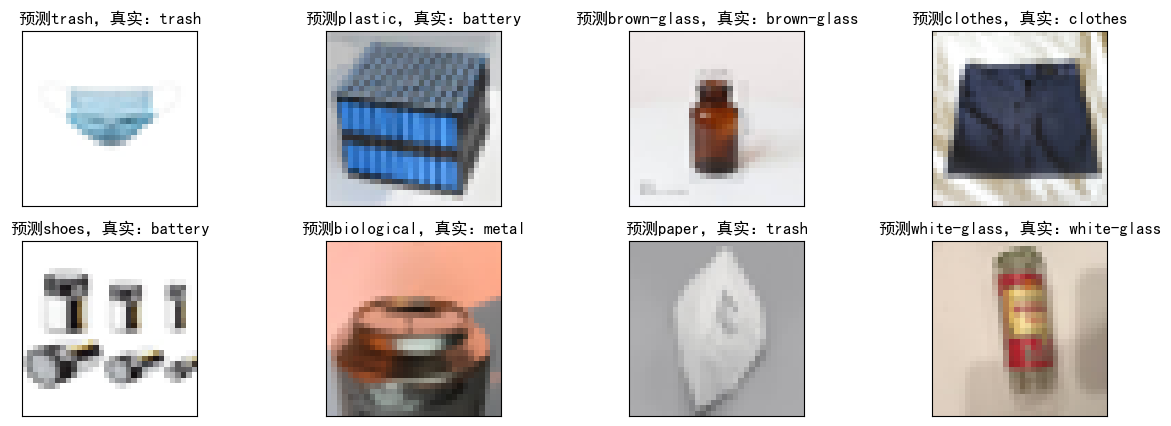

In [19]:
plt.rcParams['font.sans-serif'] = ['SimHei']
titles = [f"预测{labelNameDict[pre]}，真实：{labelNameDict[label]}" for pre, label in zip(out.tolist(), y.tolist())]
image = [img for img in x.permute(0, 2, 3, 1).numpy()]
plt.figure(figsize=(50, 50))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(image[i])
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show